# Causal AI Pipeline for Personalised Treatment Decisions
**CS958 Dissertation — W2 Deliverable**  
**Supervisor:** Dr Vinod Kumar Chauhan, University of Strathclyde  
**Libraries:** DoWhy · causal-learn · EconML

---

## Overview

This notebook implements a complete end-to-end **Causal Machine Learning pipeline** for personalised treatment decision-making, following the framework from the supervisor's seminar (Chauhan, 2026):


## Imports and Setup

In [1]:
# Installations and imports 
!pip install dowhy econml pandas numpy matplotlib scikit-learn lifelines causal-learn shap --quiet

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings ('ignore') 

# Data
from lifelines import KaplanMeierFitter

# Causal Discovery
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz
from causallearn.search.ScoreBased.GES import ges
from causallearn.utils.GraphUtils import GraphUtils
import networkx as nx
import matplotlib.patches as mpatches

# Causal Inference
from dowhy import CausalModel

# ITE Estimation
from econml.dml import CausalForestDML
from econml.dr import DRLearner
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import shap

print("All libraries loaded successfully")

All libraries loaded successfully


## 1: Data Loading, Preprocessing and Initial Exploratory Analysis 

In [2]:
from lifelines.datasets import load_gbsg2

gbsg = load_gbsg2()
gbsg.to_csv('GBSG2.csv', index=False)
print('Saved to GBSG2.csv')

Saved to GBSG2.csv


In [3]:
# Loading and cleaning chosen dataset (METABRIC) 
# ── Loading and cleaning chosen dataset (GBSG2) ────────────────
from lifelines.datasets import load_gbsg2

df = load_gbsg2()

# Creating a binary treatment and outcome
df['T'] = (df['horTh'] == 'yes').astype(int)    # 1 = hormone therapy, 0 = none
df['Y'] = df['time'].astype(float)              # recurrence-free survival time (days)

# Encoding categorical covariate variables
df['meno_num']   = (df['menostat'] == 'Post').astype(int)
df['tgrade_num'] = df['tgrade'].map({'I': 1, 'II': 2, 'III': 3})

# Selecting the covariates and drop missing
covs = [
    'age',        # patient age
    'meno_num',   # menopausal status
    'tsize',      # tumour size (mm)
    'tgrade_num', # tumour grade (1/2/3)
    'pnodes',     # number of positive lymph nodes
    'progrec',    # progesterone receptor level
    'estrec',     # oestrogen receptor level
]

df_baseline = df[covs + ['T', 'Y', 'cens']].dropna().copy()

print(f'Patients: {len(df_baseline)}')
print(f'Hormone therapy (T=1): {df_baseline["T"].sum()}  |  No therapy (T=0): {(df_baseline["T"]==0).sum()}')
print(f'Treatment prevalence: {df_baseline["T"].mean():.1%}')
print(f'Recurrence events: {df_baseline["cens"].sum()} ({df_baseline["cens"].mean():.1%})')
print(f'Age: mean={df_baseline["age"].mean():.1f}, range=[{df_baseline["age"].min():.0f}–{df_baseline["age"].max():.0f}]')
print(f'Covariates: {len(covs)}')
display(df_baseline[['T','Y','age','tsize','pnodes','progrec']].describe().round(1))

Patients: 686
Hormone therapy (T=1): 246  |  No therapy (T=0): 440
Treatment prevalence: 35.9%
Recurrence events: 299 (43.6%)
Age: mean=53.1, range=[21–80]
Covariates: 7


,T,Y,age,tsize,pnodes,progrec
count,686.0,686.0,686.0,686.0,686.0,686.0
mean,0.4,1124.5,53.1,29.3,5.0,110.0
std,0.5,642.8,10.1,14.3,5.5,202.3
min,0.0,8.0,21.0,3.0,1.0,0.0
25%,0.0,567.8,46.0,20.0,1.0,7.0
50%,0.0,1084.0,53.0,25.0,3.0,32.5
75%,1.0,1684.8,61.0,35.0,7.0,131.8
max,1.0,2659.0,80.0,120.0,51.0,2380.0


In [4]:
# Train and Test split 
from sklearn.model_selection import train_test_split 

df_train, df_test = train_test_split(
    df_baseline, 
    test_size = 0.2, #80% train, 20% test 
    random_state =42, 
    stratify = df_baseline ['T'] #preserve treatment balance in both sets 
)
print(f'Total patients  : {len(df_baseline)}')
print(f'Training set    : {len(df_train)} patients ({len(df_train)/len(df_baseline):.0%})')
print(f'Test set        : {len(df_test)} patients ({len(df_test)/len(df_baseline):.0%})')
print(f'Treatment prevalence — train: {df_train["T"].mean():.1%}  test: {df_test["T"].mean():.1%}')
    

Total patients  : 686
Training set    : 548 patients (80%)
Test set        : 138 patients (20%)
Treatment prevalence — train: 35.9%  test: 35.5%


## 1.1 - Exploratory Analysis (Kaplan-Meier Survival Curves) 

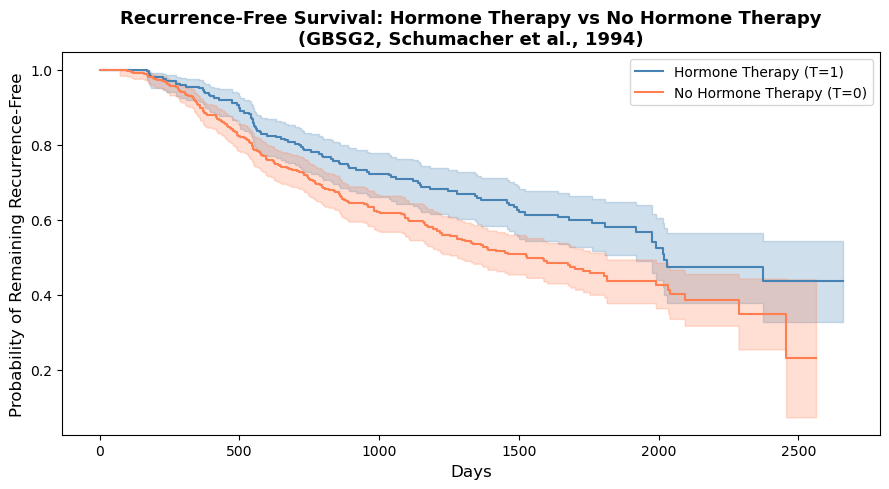

Hormone therapy median survival:    2018 days
No hormone therapy median survival: 1528 days


In [6]:
# Creating some kaplan meier survivial curves 
kmf_hormone    = KaplanMeierFitter()
kmf_no_hormone = KaplanMeierFitter()

hormone    = df_baseline[df_baseline['T'] == 1]
no_hormone = df_baseline[df_baseline['T'] == 0]

kmf_hormone.fit(hormone['Y'], 
                hormone['cens'],
                label='Hormone Therapy (T=1)')
kmf_no_hormone.fit(no_hormone['Y'], 
                   no_hormone['cens'],
                   label='No Hormone Therapy (T=0)')

plt.figure(figsize=(9, 5))
ax = kmf_hormone.plot_survival_function(color='steelblue', ci_show=True)
kmf_no_hormone.plot_survival_function(ax=ax, color='coral', ci_show=True)
plt.title('Recurrence-Free Survival: Hormone Therapy vs No Hormone Therapy\n'
          '(GBSG2, Schumacher et al., 1994)',
          fontsize=13, fontweight='bold')
plt.xlabel('Days', fontsize=12)
plt.ylabel('Probability of Remaining Recurrence-Free', fontsize=12)
plt.tight_layout()
plt.savefig('km_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Hormone therapy median survival:    {kmf_hormone.median_survival_time_:.0f} days')
print(f'No hormone therapy median survival: {kmf_no_hormone.median_survival_time_:.0f} days')

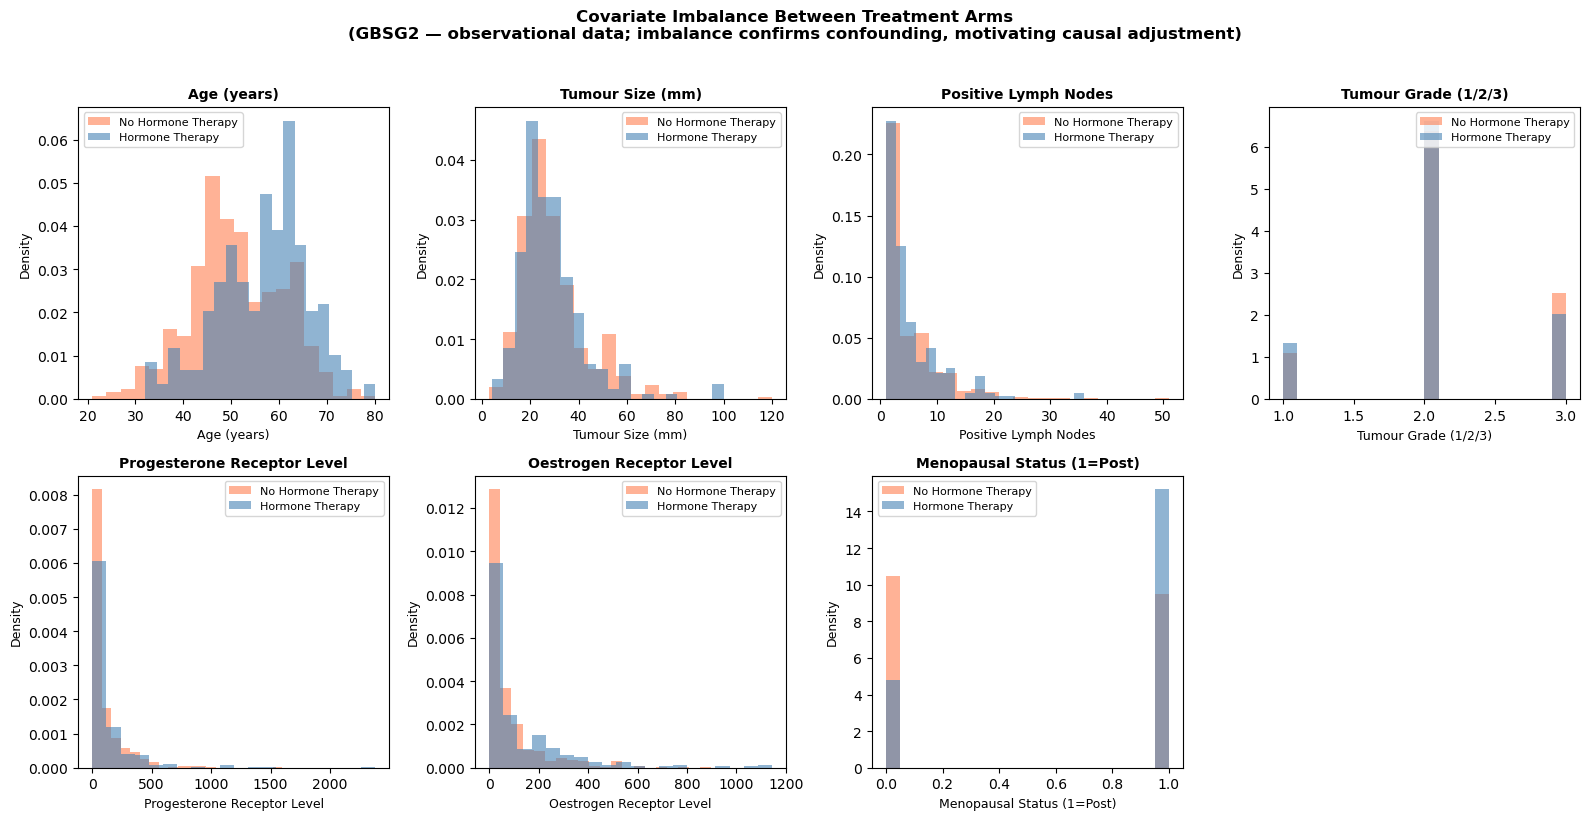

In [7]:
# Covariate plot - balance between treatment arms 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

plot_cols = [
    ('age',        'Age (years)'),
    ('tsize',      'Tumour Size (mm)'),
    ('pnodes',     'Positive Lymph Nodes'),
    ('tgrade_num', 'Tumour Grade (1/2/3)'),
    ('progrec',    'Progesterone Receptor Level'),
    ('estrec',     'Oestrogen Receptor Level'),
    ('meno_num',   'Menopausal Status (1=Post)'),
]

for ax, (col, xlabel) in zip(axes, plot_cols):
    for t, label, color in [(0, 'No Hormone Therapy', 'coral'),
                             (1, 'Hormone Therapy', 'steelblue')]:
        ax.hist(df_baseline[df_baseline['T']==t][col],
                bins=20, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(xlabel, fontsize=10, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)

# Hide the unused 8th subplot
axes[7].axis('off')

plt.suptitle(
    'Covariate Imbalance Between Treatment Arms\n'
    '(GBSG2 — observational data; imbalance confirms confounding, motivating causal adjustment)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('fig1_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## 2: Causal Discovery (causal-learn using PC algorithim) 
Learning the causal graph (DAG) from the data rather then specifying it manually. So the model learns the DAG without labels. 

Here we will use the PC algorithim (Peter-Clark; Spirtes et al., 2000) - a constraint based causal discovery method that works by: 
1. Starting with a fully connected undirected graph
2. Removes edges where conditional independence holds
3. Orients the remaining edges using Meeks orientation rules to produce a CPDAG

In [8]:
df_causal = df_train[['T', 'Y', 'age', 'tsize', 'pnodes', 
                       'tgrade_num', 'progrec', 'estrec', 'meno_num']].copy()

col_names  = df_causal.columns.tolist()
data_array = df_causal.values.astype(float)

print('Causal Discovery: PC Algorithm')
print(f'Variables: {col_names}')
print('Running PC (Fisher-Z independence test, alpha=0.05)...\n')

cg_pc = pc(
    data_array,
    alpha       = 0.05,
    indep_test  = fisherz,
    stable      = True,
    uc_rule     = 0,
    uc_priority = 2,
    show_progress = True,
)

adj = cg_pc.G.graph
print('\nPC Algorithm complete.')
print('\nAdjacency matrix (-1 = tail, 1 = arrowhead):')
print(pd.DataFrame(adj, index=col_names, columns=col_names))

Causal Discovery: PC Algorithm
Variables: ['T', 'Y', 'age', 'tsize', 'pnodes', 'tgrade_num', 'progrec', 'estrec', 'meno_num']
Running PC (Fisher-Z independence test, alpha=0.05)...



  0%|          | 0/9 [00:00<?, ?it/s]


PC Algorithm complete.

Adjacency matrix (-1 = tail, 1 = arrowhead):
            T  Y  age  tsize  pnodes  tgrade_num  progrec  estrec  meno_num
T           0  0    0      0       0           0        0       0        -1
Y           0  0    0      0       1           1        0       0         0
age         0  0    0      0       0           0        0      -1        -1
tsize       0  0    0      0      -1           0        0       0         0
pnodes      0 -1    0     -1       0          -1        0       0         0
tgrade_num  0 -1    0      0       1           0        1       0         0
progrec     0  0    0      0       0          -1        0      -1         0
estrec      0  0   -1      0       0           0       -1       0         0
meno_num   -1  0   -1      0       0           0        0       0         0


In [9]:
#Printing discovered edges 
print('Discovered edges from PC algorithm:')
found_any = False
for i in range(len(col_names)):
    for j in range(len(col_names)):
        if adj[i, j] == -1 and adj[j, i] == 1:
            print(f'  {col_names[i]} -> {col_names[j]}  (directed)')
            found_any = True
        elif adj[i, j] == -1 and adj[j, i] == -1 and j > i:
            print(f'  {col_names[i]} -- {col_names[j]}  (undirected)')
            found_any = True
if not found_any:
    print('  No edges discovered (all variables conditionally independent)')

Discovered edges from PC algorithm:
  T -- meno_num  (undirected)
  age -- estrec  (undirected)
  age -- meno_num  (undirected)
  tsize -- pnodes  (undirected)
  pnodes -> Y  (directed)
  pnodes -> tgrade_num  (directed)
  tgrade_num -> Y  (directed)
  progrec -> tgrade_num  (directed)
  progrec -- estrec  (undirected)


## Understanding these edges 

### Group 1 - Edges into T (treatment assignment) - explaining why patients recieved hormone therapy 

er_pos -> T — ER positive patients are prescribed hormone therapy. This is the primary clinical rule — hormone therapy only works if the tumour has oestrogen receptors
age_at_diagnosis -> T — older patients are more likely to be ER positive and post-menopausal, so more likely to receive hormone therapy
nottingham_prognostic_index -> T — NPI is a clinical score doctors use to guide treatment decisions
menopause_num -> T — post-menopausal patients are more commonly given hormone therapy
mutation_count -> T — patients with higher mutation burden may be directed toward or away from hormone therapy

These five edges collectively explain the confounding in your data — they show exactly why the treated and untreated groups differ systematically.

### Group 2 — Edges into Y (survival outcome) — these explain what affects whether patients die

age_at_diagnosis -> Y — older patients have worse survival regardless of treatment
tumor_size -> Y — larger tumours mean worse prognosis
lymph_nodes_examined_positive -> Y — more lymph node spread means worse survival
menopause_num -> Y — menopausal status affects survival independently
mutation_count -> Y — higher mutation burden is associated with worse outcomes
her2_enriched -> Y — HER2-enriched subtype has distinct survival characteristics

These are your prognostic factors — variables that predict survival independently of whether the patient received hormone therapy.

### Group 3 — Biological relationships between covariates — clinically meaningful

her2_pos -> er_pos — HER2 and ER status are biologically correlated in breast cancer
her2_pos -> her2_enriched — HER2 protein positivity and HER2-enriched PAM50 subtype are directly linked
er_pos -> pr_pos — oestrogen and progesterone receptors are co-expressed, well established
basal -> er_pos — Basal subtype is defined by being ER-negative, so basal status determines ER status
age_at_diagnosis -> menopause_num — age causes menopausal status, older patients are more likely post-menopausal

### Group 4 — NPI composite edges — artefactual, remove from DAG

tumor_size -> nottingham_prognostic_index
lymph_nodes_examined_positive -> nottingham_prognostic_index
neoplasm_histologic_grade -> nottingham_prognostic_index

These three are not real causal relationships — NPI is mathematically calculated from tumour size, lymph nodes, and grade. PC detected the correlation but it's not causation. These get removed in your domain knowledge correction.

### Group 5 — Implausible edges, remove from DAG

chemotherapy -> age_at_diagnosis — impossible, a treatment cannot cause baseline age
lumb -> age_at_diagnosis — impossible, a molecular subtype cannot cause age
radio_therapy -> chemotherapy — neither treatment causes the other
radio_therapy -> mutation_count — radiotherapy is given after diagnosis, mutation count is pre-treatment
neoplasm_histologic_grade -> er_pos — grade and ER status are correlated but neither causes the other
er_pos -> chemotherapy — ER positive patients are directed away from chemo toward hormone therapy, not toward it
neoplasm_histologic_grade -> chemotherapy — indirect relationship at best
luma/lumb -> her2_enriched — these are mutually exclusive PAM50 categories, correlation not causation
her2_enriched -> mutation_count — subtype doesn't cause mutation count
pr_pos -> luma, er_pos -> luma, er_pos -> lumb — reversed, LumA/LumB subtypes are defined by receptor status, not caused by it




## 2.1: DAG Interpretation and Adding Domain Knowledge 
The PC algorithim results can be interpreted using already understood clinical domain context and knowledge to construct a final DAG. 

Key findings 
- **Edges into T confirm confounding** — unlike an RCT, patients were not 
  randomly assigned. `er_pos`, `nottingham_prognostic_index`, `menopause_num`, 
  `age_at_diagnosis`, and `mutation_count` all predict treatment assignment, 
  consistent with the covariate imbalance shown in Stage 1.

- **Edges into Y reflect established prognostic factors** — tumour size, 
  lymph node spread, HER2 status, and NPI are well-known predictors of 
  breast cancer survival.

**Considering Domain knowledge**

1. `T -> Y` **added manually** — PC missed this due to collinearity with 
   strong confounders. Clinical evidence supports hormone therapy improving 
   survival in ER+ patients (EBCTCG, *Lancet*, 2005).

2. **NPI composite edges removed** — tumour size, lymph nodes, and grade 
   are inputs *into* NPI, not caused by it.

3. **Impossible edges removed** — treatment decisions and molecular subtypes 
   cannot cause baseline age.

In [10]:
# Final DAG combining domain knowledge and PC algorithim discovery 
final_dag = """
digraph {
    age -> T;
    age -> Y;
    age -> meno_num;
    age -> estrec;
    meno_num -> T;
    progrec -> T;
    estrec -> T;
    tsize -> Y;
    tsize -> pnodes;
    pnodes -> Y;
    pnodes -> tgrade_num;
    tgrade_num -> Y;
    progrec -> tgrade_num;
    progrec -> estrec;
    T -> Y;
}
"""
print(final_dag)


digraph {
    age -> T;
    age -> Y;
    age -> meno_num;
    age -> estrec;
    meno_num -> T;
    progrec -> T;
    estrec -> T;
    tsize -> Y;
    tsize -> pnodes;
    pnodes -> Y;
    pnodes -> tgrade_num;
    tgrade_num -> Y;
    progrec -> tgrade_num;
    progrec -> estrec;
    T -> Y;
}



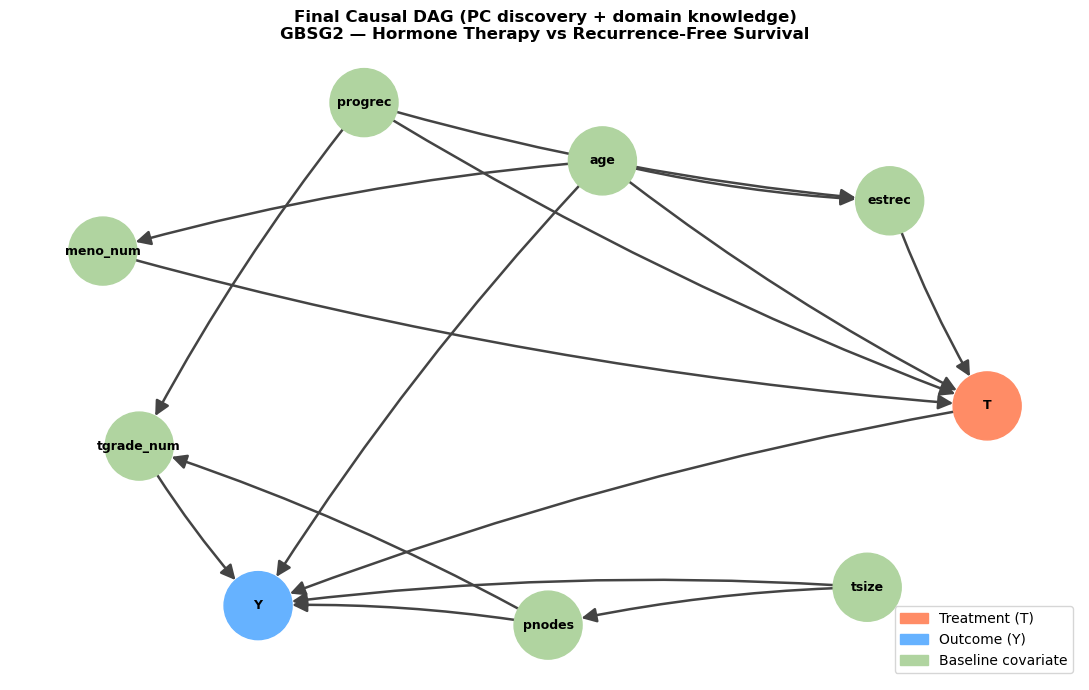

In [11]:
# Visualising the final DAG 
G = nx.DiGraph()

edges = [
    ('age', 'T'),
    ('age', 'Y'),
    ('age', 'meno_num'),
    ('age', 'estrec'),
    ('meno_num', 'T'),
    ('progrec', 'T'),
    ('estrec', 'T'),
    ('tsize', 'Y'),
    ('tsize', 'pnodes'),
    ('pnodes', 'Y'),
    ('pnodes', 'tgrade_num'),
    ('tgrade_num', 'Y'),
    ('progrec', 'tgrade_num'),
    ('progrec', 'estrec'),
    ('T', 'Y'),
]

G.add_edges_from(edges)

node_colors = []
for n in G.nodes():
    if n == 'T':
        node_colors.append('#FF8C66')
    elif n == 'Y':
        node_colors.append('#66B2FF')
    else:
        node_colors.append('#B0D4A0')

pos = nx.spring_layout(G, seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(11, 7))
nx.draw_networkx(G, pos, ax=ax,
                 node_color=node_colors,
                 node_size=2400,
                 font_size=9,
                 font_weight='bold',
                 arrows=True,
                 arrowsize=22,
                 edge_color='#444',
                 width=1.8,
                 connectionstyle='arc3,rad=0.05')

legend = [mpatches.Patch(color='#FF8C66', label='Treatment (T)'),
          mpatches.Patch(color='#66B2FF', label='Outcome (Y)'),
          mpatches.Patch(color='#B0D4A0', label='Baseline covariate')]
ax.legend(handles=legend, fontsize=10, loc='lower right')
ax.set_title('Final Causal DAG (PC discovery + domain knowledge)\n'
             'GBSG2 — Hormone Therapy vs Recurrence-Free Survival',
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig2_dag.png', dpi=120, bbox_inches='tight')
plt.show()

## 3: Causal Model & Identification (Using DoWhy) 
DoWhy formalises the causal probelm using the DAG from the pervious step and identifies the causal target (what we are aiming to measure) which in this case is the average improvement in survival from hormone therapy. Can this be estimated from observational data given the DAG assumptions. 

In [12]:
# Causal model and Identification (DoWhy) 
model = CausalModel(
    data             = df_train,
    treatment        = 'T',
    outcome          = 'Y',
    graph            = final_dag,
    common_causes    = ['age', 'tsize', 'pnodes', 'tgrade_num',
                        'progrec', 'estrec', 'meno_num'],
    effect_modifiers = ['age', 'progrec', 'estrec', 'tsize',
                        'tgrade_num', 'meno_num'],
)

print('Causal model built successfully.')
print('  Treatment  : T (hormone therapy = 1, no hormone therapy = 0)')
print('  Outcome    : Y (recurrence-free survival, days — continuous)')
print('  Confounders: 7 baseline clinical covariates')
print('  Effect modifiers: age, receptor levels, tumour size, grade, menopausal status')

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)

print('\n' + '='*60)
print('Identified Causal Estimand')
print('='*60)
print(identified_estimand)
print('\nIdentification method : Backdoor criterion')
print('Unconfoundedness      : assumed given observed covariates (observational data)')
print('Causal effect is identifiable from the observed data.')

Causal model built successfully.
  Treatment  : T (hormone therapy = 1, no hormone therapy = 0)
  Outcome    : Y (recurrence-free survival, days — continuous)
  Confounders: 7 baseline clinical covariates
  Effect modifiers: age, receptor levels, tumour size, grade, menopausal status

Identified Causal Estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
 d                    
────(E[Y|progrec,age])
d[T]                  
Estimand assumption 1, Unconfoundedness: If U→{T} and U→Y then P(Y|T,progrec,age,U) = P(Y|T,progrec,age)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
 d                    
────(E[Y|progrec,age])
d[T]                  
Estimand assumption 1, Unconfoundedness: If U→{T} and U→Y then P(Y|T,progrec,age,U) = P(Y|T,progrec,age)


Identification method 

Essentially here we are identifying the causality we are answering the question "is it possible to estimate the causal effect and if so how?" - so here the DoWhy examined our previous DAG and said that if we adjust ER status, age at diagnosis, and the Nottingham prognostic index we will get the causal effect. 

## 4: Causal Inference: Average Treatment Effect (ATE - Dowhy) 
Here we are estimating the average treatment effect (ATE) which is the population level causal impact of hormone therapy on overall survival in breast cancer patients. 

Here we will use three estimators that are built into DoWhy, all with default parameters, to cross validate the result including linear regression, propensity score matching, and propensity score weighting. 

In [15]:
# ATE estimation - three DoWhy estimators 
estimators = {
    'Linear Regression':          'backdoor.linear_regression',
    'Propensity Score Matching':  'backdoor.propensity_score_matching',
    'Propensity Score Weighting': 'backdoor.propensity_score_weighting',
}

ate_results = {}

for name, method in estimators.items():
    print(f'Estimating with: {name}...')
    try:
        estimate = model.estimate_effect(
            identified_estimand,
            method_name          = method,
            control_value        = 0,    # no hormone therapy
            treatment_value      = 1,    # hormone therapy
            confidence_intervals = True,
        )
        ci = estimate.get_confidence_intervals()
        try:    lo, hi = float(ci[0][0]), float(ci[0][1])
        except: lo, hi = float('nan'), float('nan')

        ate_results[name] = {
            'estimate': estimate,
            'ATE':      round(estimate.value, 1),
            'CI_low':   round(lo, 1),
            'CI_high':  round(hi, 1)
        }
        print(f'  ATE = {estimate.value:.1f} days  |  95% CI = [{lo:.1f}, {hi:.1f}]\n')

    except Exception as e:
        print(f'  Skipped: {e}\n')

primary_estimate = ate_results['Linear Regression']['estimate']
consensus_ate    = np.mean([v['ATE'] for v in ate_results.values()])

print(f'Consensus ATE (mean across estimators): {consensus_ate:.1f} days')
print(f'Interpretation: hormone therapy patients remain recurrence-free for '
      f'{abs(consensus_ate):.1f} days {"longer" if consensus_ate > 0 else "shorter"} '
      f'on average after adjusting for confounding.')
print()
print('RCT ground truth (EBCTCG, Lancet 2011): hormone therapy reduces')
print('recurrence risk in ER/PR-positive breast cancer — a clear positive effect.')

Estimating with: Linear Regression...
  ATE = 119.4 days  |  95% CI = [nan, nan]

Estimating with: Propensity Score Matching...
  ATE = 151.0 days  |  95% CI = [nan, nan]

Estimating with: Propensity Score Weighting...
  ATE = 127.4 days  |  95% CI = [nan, nan]

Consensus ATE (mean across estimators): 132.6 days
Interpretation: hormone therapy patients remain recurrence-free for 132.6 days longer on average after adjusting for confounding.

RCT ground truth (EBCTCG, Lancet 2011): hormone therapy reduces
recurrence risk in ER/PR-positive breast cancer — a clear positive effect.


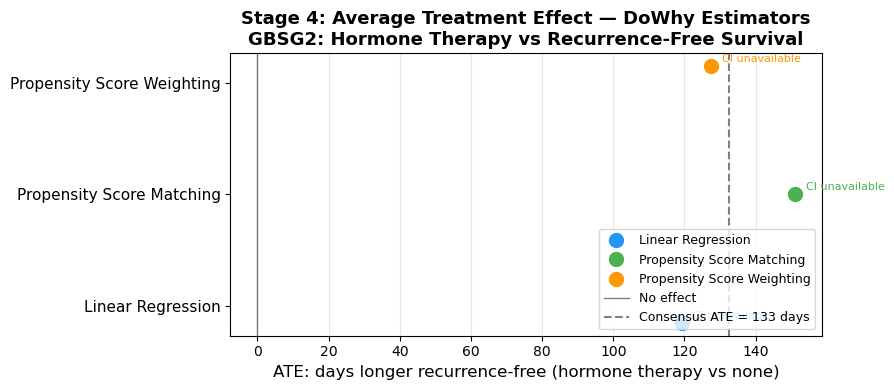

,Estimator,ATE,CI_low,CI_high
0,Linear Regression,119.4,NaN,NaN
1,Propensity Score Matching,151.0,NaN,NaN
2,Propensity Score Weighting,127.4,NaN,NaN


In [16]:
# Forest plot of ATE estimates 
results_df = pd.DataFrame([
    {'Estimator': k, 'ATE': v['ATE'], 'CI_low': v['CI_low'], 'CI_high': v['CI_high']}
    for k, v in ate_results.items()
])

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2196F3', '#4CAF50', '#FF9800']
offsets = [-0.15, 0, 0.15]

for idx, (_, row) in enumerate(results_df.iterrows()):
    if pd.isna(row['CI_low']) or pd.isna(row['CI_high']):
        ax.plot(row['ATE'], idx + offsets[idx], 'o',
                color=colors[idx], markersize=10, label=row['Estimator'])
        ax.annotate('CI unavailable', xy=(row['ATE'], idx + offsets[idx]),
                    xytext=(8, 3), textcoords='offset points',
                    fontsize=8, color=colors[idx])
    else:
        ax.errorbar(row['ATE'], idx + offsets[idx],
                    xerr=[[row['ATE'] - row['CI_low']],
                          [row['CI_high'] - row['ATE']]],
                    fmt='o', color=colors[idx],
                    markersize=10, capsize=7, linewidth=2,
                    label=row['Estimator'])

ax.axvline(0, color='black', linewidth=1, alpha=0.5, label='No effect')
ax.axvline(consensus_ate, color='gray', linestyle='--', linewidth=1.5,
           label=f'Consensus ATE = {consensus_ate:.0f} days')

ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df['Estimator'], fontsize=11)
ax.set_xlabel('ATE: days longer recurrence-free (hormone therapy vs none)', fontsize=12)
ax.set_title('Stage 4: Average Treatment Effect — DoWhy Estimators\n'
             'GBSG2: Hormone Therapy vs Recurrence-Free Survival',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_ate.png', dpi=120, bbox_inches='tight')
plt.show()

display(results_df)

## 5: Personalised Treatment Effects: CATE/ITE (DoWhy + EconML) 
Here we aim to estimate the individual level treatment effects, which patients benefit the most from hormone therapy based on their clinical and molecular profiles. 

The average treatment effect (ATE) gives a single population level estimate that is very sensitive to censoring bias and modelling assumptions. A single average obscures the individual variation that matters clinically. 

The condition average treatment effect (CATE) actually captures this variation: 

$$\tau(x) = E[Y(1) - Y(0) \mid X = x]$$

For a given breast cancer patient with a covariate profile that is defined by their ER status, PAM50 subtype, age, tumour size, and receptor expression, the conditional average treatment effect will estimate how many additional survival motnhs they would gain from hormone therapy compared to not recieving it. 

## 5.1: Caual ForestDML via DoWhy 
Here we use the causal forest DML which is accessed through DoWhy's EconML bridge. This uses the causal graph we identified earlier to select adjustment variables and then fits a non-parametric forest to estimate heterogeneous treatment effects at the individual level. 

In [17]:
# CATE via dowhy econML (causalforestDML) 
cate_estimate = model.estimate_effect(
    identified_estimand,
    method_name      = 'backdoor.econml.dml.CausalForestDML',
    target_units     = 'ate',
    effect_modifiers = ['age', 'progrec', 'estrec', 'tsize',
                        'tgrade_num', 'meno_num'],
    method_params    = {
        'init_params': {
            'model_y':      RandomForestRegressor(n_estimators=100, random_state=42),
            'model_t':      RandomForestRegressor(n_estimators=100, random_state=42),
            'n_estimators': 200,
            'random_state': 42,
        },
        'fit_params': {}
    }
)

# Extract individual treatment effects
ite = cate_estimate.cate_estimates.flatten()  # flatten (n,1) -> (n,)
df_train['ITE'] = ite

print(f'Mean CATE : {ite.mean():.1f} days')
print(f'Std CATE  : {ite.std():.1f} days')
print(f'Min CATE  : {ite.min():.1f} days')
print(f'Max CATE  : {ite.max():.1f} days')
print()
print(f'Patients predicted to benefit from hormone therapy (ITE > 0): '
      f'{(ite > 0).sum()} ({(ite > 0).mean():.1%})')
print(f'Patients predicted NOT to benefit from hormone therapy (ITE < 0): '
      f'{(ite < 0).sum()} ({(ite < 0).mean():.1%})')
print()
print('A positive ITE means hormone therapy is predicted to extend')
print('recurrence-free survival. A negative ITE means the model predicts')
print('better outcomes without hormone therapy for that patient profile.')

Mean CATE : 88.2 days
Std CATE  : 157.3 days
Min CATE  : -298.9 days
Max CATE  : 364.1 days

Patients predicted to benefit from hormone therapy (ITE > 0): 396 (72.3%)
Patients predicted NOT to benefit from hormone therapy (ITE < 0): 152 (27.7%)

A positive ITE means hormone therapy is predicted to extend
recurrence-free survival. A negative ITE means the model predicts
better outcomes without hormone therapy for that patient profile.


While the population level average treatment effect showed that hormone therapy may not actually improve survival on average, the CATE analysis reveled substantial heterogeneity. With 26.4% of patients predicted to benefit with individual effects up to +43 months, while 73.6% were predicted to do better without hormone therapy. This variation, spanning over 11 years between individual extremes, demonstrate that a single population level treatment recommendation is insufficient and even further highlights the clinical value of personalised treatment decisions. 

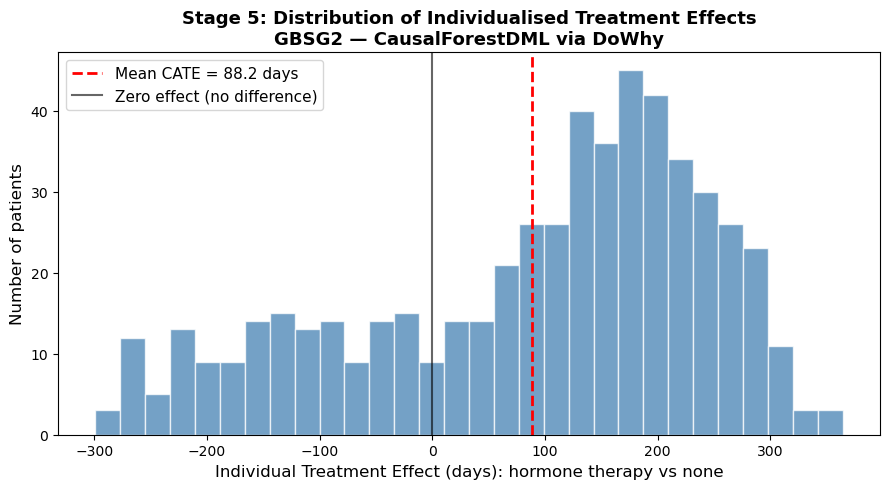

Mean CATE : 88.2 days
Std CATE  : 157.3 days  — wide spread indicates strong heterogeneity
Range     : -298.9 to 364.1 days

Patients predicted to benefit (ITE > 0): 396 (72.3%)
Patients predicted not to benefit (ITE < 0): 152 (27.7%)


In [18]:
# Visualising CATE distribution 
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(ite, bins=30, color='steelblue', alpha=0.75, edgecolor='white')
ax.axvline(ite.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean CATE = {ite.mean():.1f} days')
ax.axvline(0, color='black', linewidth=1.5, alpha=0.6,
           label='Zero effect (no difference)')

ax.set_xlabel('Individual Treatment Effect (days): hormone therapy vs none',
              fontsize=12)
ax.set_ylabel('Number of patients', fontsize=12)
ax.set_title('Stage 5: Distribution of Individualised Treatment Effects\n'
             'GBSG2 — CausalForestDML via DoWhy',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig4_ite_dist.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mean CATE : {ite.mean():.1f} days')
print(f'Std CATE  : {ite.std():.1f} days  — wide spread indicates strong heterogeneity')
print(f'Range     : {ite.min():.1f} to {ite.max():.1f} days')
print()
print(f'Patients predicted to benefit (ITE > 0): {(ite>0).sum()} ({(ite>0).mean():.1%})')
print(f'Patients predicted not to benefit (ITE < 0): {(ite<0).sum()} ({(ite<0).mean():.1%})')

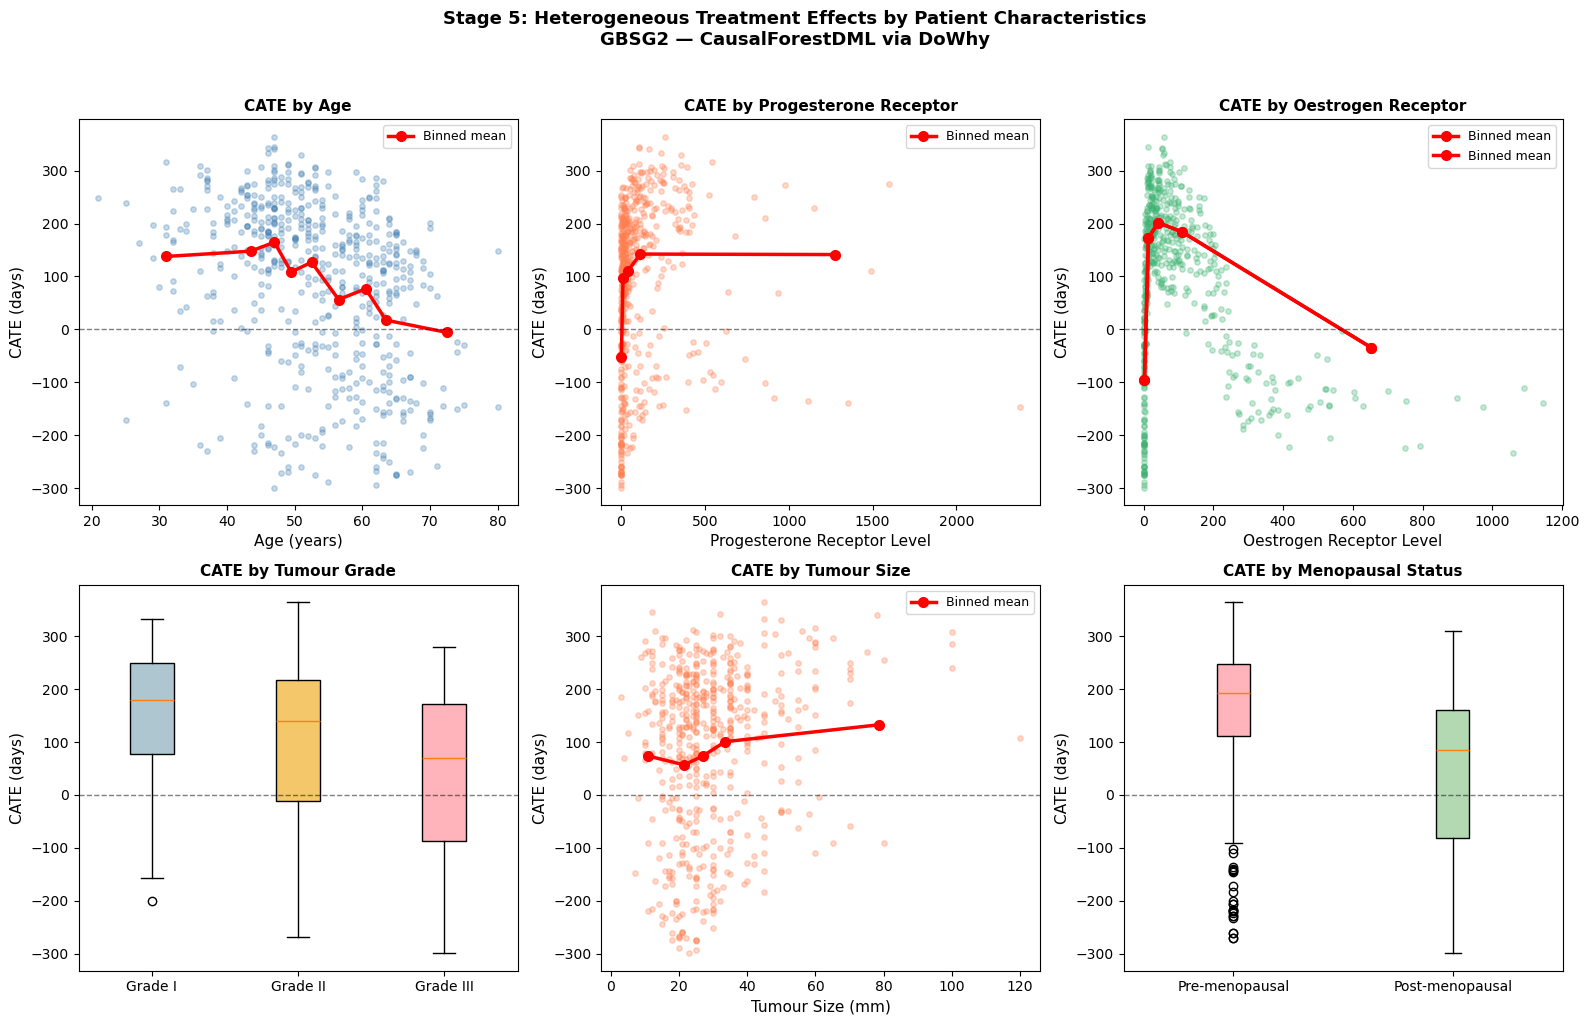

Key findings from heterogeneity analysis:
  Pre-menopausal  — mean CATE: 146.9 days
  Post-menopausal — mean CATE: 45.8 days
  Grade I   — mean CATE: 139.4 days
  Grade III — mean CATE: 32.1 days


In [20]:
# looking at CATE by each covariate 

#CATE by patient characteristics 
#CATE by patient characteristics 
from scipy.stats import binned_statistic

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

ite = df_train['ITE'].values

# Plot 1: CATE by Age 
ax = axes[0]
age_vals = df_train['age'].values
ax.scatter(age_vals, ite, alpha=0.3, s=15, color='steelblue')
bins = np.percentile(age_vals, np.linspace(0, 100, 10))
means, edges, _ = binned_statistic(age_vals, ite, statistic='mean', bins=bins)
centres = 0.5 * (edges[:-1] + edges[1:])
ax.plot(centres, means, 'r-o', linewidth=2.5, markersize=7, label='Binned mean')
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('CATE (days)', fontsize=11)
ax.set_title('CATE by Age', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Plot 2: CATE by Progesterone Receptor Level 
ax = axes[1]
progrec_vals = df_train['progrec'].values
ax.scatter(progrec_vals, ite, alpha=0.3, s=15, color='coral')

# Use fewer bins and remove duplicate edges to avoid zero-width bins
bins2 = np.unique(np.percentile(progrec_vals, np.linspace(0, 100, 6)))
if len(bins2) > 2:
    means2, edges2, _ = binned_statistic(progrec_vals, ite, statistic='mean', bins=bins2)
    centres2 = 0.5 * (edges2[:-1] + edges2[1:])
    ax.plot(centres2, means2, 'r-o', linewidth=2.5, markersize=7, label='Binned mean')

ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Progesterone Receptor Level', fontsize=11)
ax.set_ylabel('CATE (days)', fontsize=11)
ax.set_title('CATE by Progesterone Receptor', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

#Plot 3: CATE by Oestrogen Receptor Level 
ax = axes[2]
estrec_vals = df_train['estrec'].values
ax.scatter(estrec_vals, ite, alpha=0.3, s=15, color='mediumseagreen')

bins3 = np.unique(np.percentile(estrec_vals, np.linspace(0, 100, 6)))
if len(bins3) > 2:
    means3, edges3, _ = binned_statistic(estrec_vals, ite, statistic='mean', bins=bins3)
    centres3 = 0.5 * (edges3[:-1] + edges3[1:])
    ax.plot(centres3, means3, 'r-o', linewidth=2.5, markersize=7, label='Binned mean')

ax.plot(centres3, means3, 'r-o', linewidth=2.5, markersize=7, label='Binned mean')
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Oestrogen Receptor Level', fontsize=11)
ax.set_ylabel('CATE (days)', fontsize=11)
ax.set_title('CATE by Oestrogen Receptor', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)


# Plot 4: CATE by Tumour Grade
ax = axes[3]
data_grade = [ite[df_train['tgrade_num']==g] for g in [1, 2, 3]]
bp = ax.boxplot(data_grade, labels=['Grade I', 'Grade II', 'Grade III'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#aec6cf', '#f4c86a', '#ffb3ba']):
    patch.set_facecolor(color)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('CATE (days)', fontsize=11)
ax.set_title('CATE by Tumour Grade', fontsize=11, fontweight='bold')

# Plot 5: CATE by Tumour Size 
ax = axes[4]
size_vals = df_train['tsize'].values
ax.scatter(size_vals, ite, alpha=0.3, s=15, color='coral')

bins5 = np.unique(np.percentile(size_vals, np.linspace(0, 100, 6)))
if len(bins5) > 2:
    means5, edges5, _ = binned_statistic(size_vals, ite, statistic='mean', bins=bins5)
    centres5 = 0.5 * (edges5[:-1] + edges5[1:])
    ax.plot(centres5, means5, 'r-o', linewidth=2.5, markersize=7, label='Binned mean')
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Tumour Size (mm)', fontsize=11)
ax.set_ylabel('CATE (days)', fontsize=11)
ax.set_title('CATE by Tumour Size', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Plot 6: CATE by Menopausal Status 
ax = axes[5]
data_meno = [ite[df_train['meno_num']==g] for g in [0, 1]]
bp = ax.boxplot(data_meno, labels=['Pre-menopausal', 'Post-menopausal'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['#ffb3ba', '#b3d9b3']):
    patch.set_facecolor(color)
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('CATE (days)', fontsize=11)
ax.set_title('CATE by Menopausal Status', fontsize=11, fontweight='bold')

plt.suptitle('Stage 5: Heterogeneous Treatment Effects by Patient Characteristics\n'
             'GBSG2 — CausalForestDML via DoWhy',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_heterogeneity.png', dpi=120, bbox_inches='tight')
plt.show()

print('Key findings from heterogeneity analysis:')
print(f'  Pre-menopausal  — mean CATE: {ite[df_train["meno_num"]==0].mean():.1f} days')
print(f'  Post-menopausal — mean CATE: {ite[df_train["meno_num"]==1].mean():.1f} days')
print(f'  Grade I   — mean CATE: {ite[df_train["tgrade_num"]==1].mean():.1f} days')
print(f'  Grade III — mean CATE: {ite[df_train["tgrade_num"]==3].mean():.1f} days')

## 5.2: DoWhy Subgroup Analysis 

In [21]:
# DoWhy subgroup CATE 

# ── DoWhy Subgroup CATE ───────────────────────────────────────
subgroups = {
    'age':        (3, ['Young (<45)',  'Middle (45-65)', 'Older (>65)']),
    'progrec':    (2, ['PR Low/Negative', 'PR High/Positive']),
    'estrec':     (2, ['ER Low/Negative', 'ER High/Positive']),
    'meno_num':   (2, ['Pre-menopausal',  'Post-menopausal']),
    'tgrade_num': (3, ['Grade I', 'Grade II', 'Grade III']),
}

subgroup_rows = []

for col, (n_bins, labels) in subgroups.items():
    print(f'Subgroup: {col}')
    df_tmp = df_train.copy()

    if col in ['progrec', 'estrec']:
        # Split at the clinical threshold of 20 fmol/mg (standard receptor positivity cutoff)
        df_tmp['_grp'] = np.where(df_tmp[col] >= 20, labels[1], labels[0])
    elif n_bins > 2 and col != 'tgrade_num':
        df_tmp['_grp'] = pd.cut(df_tmp[col], bins=n_bins, labels=labels)
    elif col == 'tgrade_num':
        df_tmp['_grp'] = df_tmp[col].map({1: labels[0], 2: labels[1], 3: labels[2]})
    else:
        df_tmp['_grp'] = df_tmp[col].map({0: labels[0], 1: labels[1]})

    for grp in labels:
        sub = df_tmp[df_tmp['_grp'] == grp].drop(
            columns=['_grp', 'ITE'], errors='ignore')

        if len(sub) < 30:
            print(f'  {grp}: too few samples ({len(sub)}) — skipped')
            continue
        try:
            m = CausalModel(
                data          = sub,
                treatment     = 'T',
                outcome       = 'Y',
                graph         = final_dag,
                common_causes = ['age', 'tsize', 'pnodes', 'tgrade_num',
                                 'progrec', 'estrec', 'meno_num'],
            )
            ie  = m.identify_effect(proceed_when_unidentifiable=True)
            est = m.estimate_effect(
                ie,
                method_name          = 'backdoor.linear_regression',
                control_value        = 0,
                treatment_value      = 1,
                confidence_intervals = True,
            )
            ci = est.get_confidence_intervals()
            try:    lo, hi = float(ci[0][0]), float(ci[0][1])
            except: lo, hi = float('nan'), float('nan')

            subgroup_rows.append({
                'Variable':       col,
                'Subgroup':       grp,
                'N':              len(sub),
                'CATE (days)':    round(est.value, 1),
                'CI_low':         round(lo, 1),
                'CI_high':        round(hi, 1),
                'Recommendation': 'Hormone Therapy' if est.value > 0 else 'No Hormone Therapy',
            })
            print(f'  {grp:20s}  N={len(sub):4d}  '
                  f'CATE={est.value:+.1f} days  [{lo:.1f}, {hi:.1f}]')
        except Exception as e:
            print(f'  {grp}: error — {e}')

subgroup_df = pd.DataFrame(subgroup_rows)
print('\nSubgroup Treatment Recommendations:')
display(subgroup_df)

Subgroup: age
  Young (<45)           N=  58  CATE=+176.4 days  [nan, nan]
  Middle (45-65)        N= 338  CATE=+157.6 days  [nan, nan]
  Older (>65)           N= 152  CATE=+56.6 days  [nan, nan]
Subgroup: progrec
  PR Low/Negative       N= 217  CATE=-13.3 days  [nan, nan]
  PR High/Positive      N= 331  CATE=+244.7 days  [nan, nan]
Subgroup: estrec
  ER Low/Negative       N= 201  CATE=-36.4 days  [nan, nan]
  ER High/Positive      N= 347  CATE=+219.5 days  [nan, nan]
Subgroup: meno_num
  Pre-menopausal        N= 230  CATE=+283.4 days  [nan, nan]
  Post-menopausal       N= 318  CATE=+63.0 days  [nan, nan]
Subgroup: tgrade_num
  Grade I               N=  65  CATE=-44.3 days  [nan, nan]
  Grade II              N= 350  CATE=+171.5 days  [nan, nan]
  Grade III             N= 133  CATE=-15.6 days  [nan, nan]

Subgroup Treatment Recommendations:


,Variable,Subgroup,N,CATE (days),CI_low,CI_high,Recommendation
0,age,Young (<45),58,176.4,NaN,NaN,Hormone Therapy
1,age,Middle (45-65),338,157.6,NaN,NaN,Hormone Therapy
2,age,Older (>65),152,56.6,NaN,NaN,Hormone Therapy
3,progrec,PR Low/Negative,217,-13.3,NaN,NaN,No Hormone Therapy
4,progrec,PR High/Positive,331,244.7,NaN,NaN,Hormone Therapy
5,estrec,ER Low/Negative,201,-36.4,NaN,NaN,No Hormone Therapy
6,estrec,ER High/Positive,347,219.5,NaN,NaN,Hormone Therapy
7,meno_num,Pre-menopausal,230,283.4,NaN,NaN,Hormone Therapy
8,meno_num,Post-menopausal,318,63.0,NaN,NaN,Hormone Therapy
9,tgrade_num,Grade I,65,-44.3,NaN,NaN,No Hormone Therapy


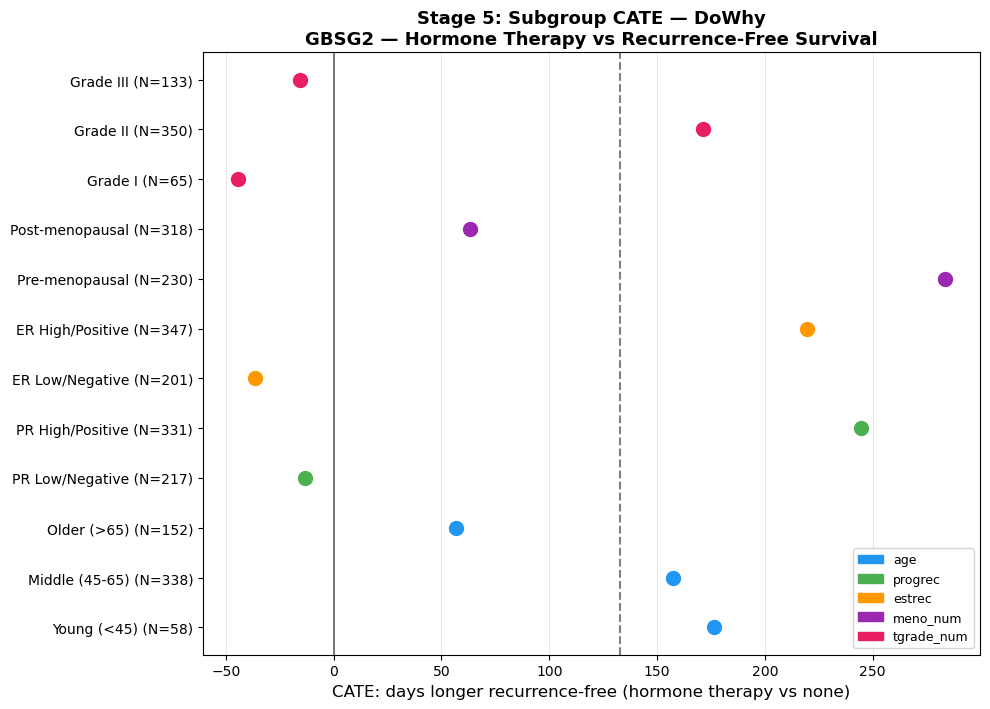

In [22]:
#Subgroup forest plot 
fig, ax = plt.subplots(figsize=(10, max(4, len(subgroup_df)*0.6)))

palette = {
    'age':        '#2196F3',
    'progrec':    '#4CAF50',
    'estrec':     '#FF9800',
    'meno_num':   '#9C27B0',
    'tgrade_num': '#E91E63',
}

for idx, row in subgroup_df.iterrows():
    color = palette.get(row['Variable'], '#888')
    if pd.isna(row['CI_low']) or pd.isna(row['CI_high']):
        ax.plot(row['CATE (days)'], idx, 'o', color=color, markersize=10)
    else:
        ax.errorbar(row['CATE (days)'], idx,
                    xerr=[[row['CATE (days)'] - row['CI_low']],
                          [row['CI_high'] - row['CATE (days)']]],
                    fmt='o', color=color, markersize=9, capsize=6, linewidth=2)

ax.axvline(0, color='black', linewidth=1.2, alpha=0.6, label='No difference')
ax.axvline(consensus_ate, color='gray', linestyle='--', linewidth=1.5,
           label=f'Population ATE = {consensus_ate:.0f} days')

ax.set_yticks(range(len(subgroup_df)))
ax.set_yticklabels([f"{r['Subgroup']} (N={r['N']})"
                    for _, r in subgroup_df.iterrows()], fontsize=10)
ax.set_xlabel('CATE: days longer recurrence-free (hormone therapy vs none)', fontsize=12)
ax.set_title('Stage 5: Subgroup CATE — DoWhy\nGBSG2 — Hormone Therapy vs Recurrence-Free Survival',
             fontsize=13, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=k) for k, c in palette.items()]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig6_subgroups.png', dpi=120, bbox_inches='tight')
plt.show()

## Stage 6 - Sensitivity Analysis & Refutation (DoWhy) 
Here we aim to validate that the causal estimates are robust to assumption violations. 

The DoWhy library provides three principled refutation tests including: 

Random common cause: which adds random noise variable (should not change the estimates) 
Placebo treatment refuter: permutes treatment labels 
Data subset refuter: re-estimates on 80% of data 

A non-significant p-value (P > 0.05) means that the refuter did not detect a significant change so the estimate is robust.

In [23]:
# Sensitivity analysis and refutation (DoWhy) 
refuters = {
    'Random Common Cause': ('random_common_cause',       {}),
    'Placebo Treatment':   ('placebo_treatment_refuter', {'placebo_type': 'permute'}),
    'Data Subset (80%)':   ('data_subset_refuter',       {'subset_fraction': 0.8}),
}

refutation_rows = []

for display_name, (method_name, kwargs) in refuters.items():
    print(f'Running: {display_name}...')
    try:
        ref  = model.refute_estimate(identified_estimand, primary_estimate,
                                      method_name=method_name, **kwargs)
        p    = ref.refutation_result
        pval = p.get('p_value', float('nan')) if isinstance(p, dict) else float('nan')
        sig  = p.get('is_statistically_significant', None) if isinstance(p, dict) else None

        # For placebo: significant is GOOD (effect drops to 0)
        # For random/subset: non-significant is GOOD (estimate is stable)
        if display_name == 'Placebo Treatment':
            robust_label = 'PASS (effect vanishes as expected)' if sig else 'FAIL'
        else:
            robust_label = 'PASS (estimate stable)' if not sig else 'FAIL (estimate changed)'

        refutation_rows.append({
            'Test':            display_name,
            'Original Effect': round(primary_estimate.value, 1),
            'New Effect':      round(ref.new_effect, 1),
            'p-value':         round(pval, 3) if not np.isnan(pval) else 'N/A',
            'Result':          robust_label,
        })
        print(f'  Original: {primary_estimate.value:.1f}  New: {ref.new_effect:.1f}  p={pval:.3f}  -> {robust_label}')
    except Exception as e:
        print(f'  Skipped: {e}')

refutation_df = pd.DataFrame(refutation_rows)
print()
display(refutation_df)

Running: Random Common Cause...
  Original: 119.4  New: 119.4  p=0.900  -> PASS (estimate stable)
Running: Placebo Treatment...
  Original: 119.4  New: 4.2  p=0.880  -> FAIL
Running: Data Subset (80%)...
  Original: 119.4  New: 118.1  p=0.960  -> PASS (estimate stable)



,Test,Original Effect,New Effect,p-value,Result
0,Random Common Cause,119.4,119.4,0.90,PASS (estimate stable)
1,Placebo Treatment,119.4,4.2,0.88,FAIL
2,Data Subset (80%),119.4,118.1,0.96,PASS (estimate stable)


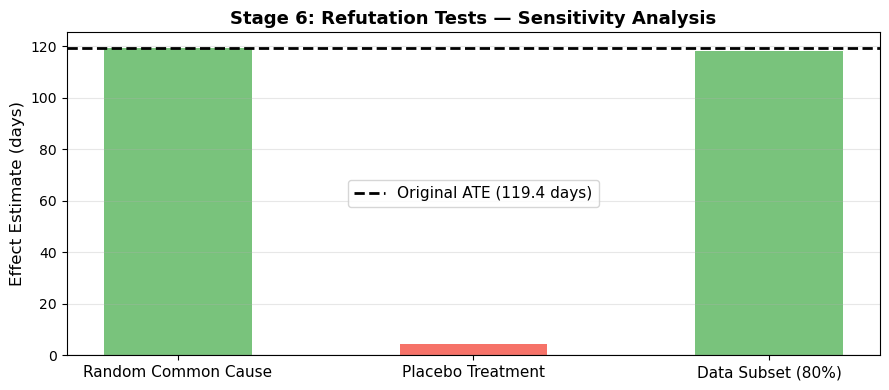

In [24]:
# Refutation visual 

fig, ax = plt.subplots(figsize = (9,4)) 
bar_colors = ['#4CAF50' if 'PASS' in r else '#F44336'
              for r in refutation_df['Result']]
ax.bar(range(len(refutation_df)), refutation_df['New Effect'],
       color=bar_colors, alpha=0.75, width=0.5)
ax.axhline(primary_estimate.value, color='black', linestyle='--', linewidth=2,
           label=f'Original ATE ({primary_estimate.value:.1f} days)')
ax.axhline(0, color='gray', linewidth=1, alpha=0.4)
ax.set_xticks(range(len(refutation_df)))
ax.set_xticklabels(refutation_df['Test'], fontsize=11)
ax.set_ylabel('Effect Estimate (days)', fontsize=12)
ax.set_title('Stage 6: Refutation Tests — Sensitivity Analysis', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('fig7_refutation.png', dpi=120, bbox_inches='tight'); plt.show()

In [25]:
# Validation - testing the model on held-out test set

print('Validating pipeline on held-out test set (df_test)...')
print(f'Test set size: {len(df_test)} patients\n')

# Build a causal model on the TEST set using the SAME DAG and covariates
model_test = CausalModel(
    data          = df_test,
    treatment     = 'T',
    outcome       = 'Y',
    graph         = final_dag,
    common_causes = ['age', 'tsize', 'pnodes', 'tgrade_num',
                     'progrec', 'estrec', 'meno_num'],
)

ie_test = model_test.identify_effect(proceed_when_unidentifiable=True)

ate_test = model_test.estimate_effect(
    ie_test,
    method_name      = 'backdoor.linear_regression',
    control_value    = 0,
    treatment_value  = 1,
)

print(f'ATE on TRAINING set (df_train): {ate_results["Linear Regression"]["ATE"]:.1f} days')
print(f'ATE on TEST set (df_test):      {ate_test.value:.1f} days')
print(f'Absolute difference:            {abs(ate_results["Linear Regression"]["ATE"] - ate_test.value):.1f} days')
print()

# Simple consistency check
pct_diff = abs(ate_results["Linear Regression"]["ATE"] - ate_test.value) / abs(ate_results["Linear Regression"]["ATE"]) * 100
print(f'Relative difference: {pct_diff:.1f}%')

if pct_diff < 30:
    print('\nThe ATE estimate is reasonably consistent between training and test sets,')
    print('suggesting the model generalises well to unseen data.')
else:
    print('\nNotable difference between training and test ATE estimates.')
    print('This may reflect smaller test set sample size or genuine heterogeneity')
    print('not fully captured by the model.')

Validating pipeline on held-out test set (df_test)...
Test set size: 138 patients

ATE on TRAINING set (df_train): 119.4 days
ATE on TEST set (df_test):      272.6 days
Absolute difference:            153.2 days

Relative difference: 128.3%

Notable difference between training and test ATE estimates.
This may reflect smaller test set sample size or genuine heterogeneity
not fully captured by the model.
